# Pseudotime Analysis — Worksheet
**Bone marrow mononuclear cells · NeurIPS 2021 benchmarking dataset**

---

This worksheet will walk you through performing **Diffusion Pseudotime (DPT)** analysis on the B cell lineage from a bone marrow single-cell RNA-seq dataset that has already been preprocessed and annotated with CellTypist.

Your job is to **fill in every code cell yourself**. Each section gives you the concept, the goal, and a hint about which function to use. Resist the urge to copy — the more you type it out, the more it sticks.

---

## What is pseudotime?

Single-cell RNA-seq captures a **snapshot** of a tissue — all cells at one moment in time. But cells at different stages of differentiation are all present simultaneously. **Pseudotime** is a computational way of ordering cells along a trajectory from most immature → most mature, based solely on transcriptomic similarity.

**Diffusion Pseudotime (DPT)** works by:
1. Building a **diffusion map** — a low-dimensional embedding that emphasises continuous transitions between cell states (think of it like PCA but optimised for trajectories, not variance).
2. Defining a **root cell** — the most immature cell, which anchors the start of the trajectory.
3. Computing a **pseudotime score** for every cell: the diffusion distance from that root.

---

## Why subset by lineage?

This dataset contains ~17,000 cells from many immune lineages (T cells, B cells, erythroid, monocytes…). If you run DPT on the whole object, the diffusion map will be dominated by the largest population (T cells: ~5,500 cells) and the trajectories you care about will be obscured.

**Always subset to the lineage of interest before running pseudotime.**

---

## The lineage you will analyse

| Lineage | Cell types (in order) | Column to use |
|---|---|---|
| B cell | Pro-B cells → Small pre-B cells → Naive B cells → Plasma cells | `celltypist_low` |

---

## Step 0 — Imports & settings

Import `scanpy`, `numpy`, and `matplotlib.pyplot`. Set scanpy verbosity to 1 and figure params to dpi=100 with no frame.

> **Hint**: `sc.settings.verbosity`, `sc.settings.set_figure_params(...)`

In [ ]:
# your code here


## Step 1 — Load the data

Load `bone_marrow_celltypist.h5ad` and print the AnnData object to inspect it.

> **Hint**: `sc.read_h5ad(...)`

After loading, check what columns are in `adata.obs` — you'll need `celltypist_low` and `celltypist_high`.

In [ ]:
# your code here


---
# B Cell Lineage

Expected biological order: **Pro-B cells → Small pre-B cells → Naive B cells → Plasma cells**

Known marker genes to validate: `VPREB1`, `IGLL1` (pro/pre-B), `CD79A`, `CD79B`, `MS4A1` (mature B), `MZB1`, `JCHAIN` (plasma)

This time, all cell types come from `celltypist_low` — no need to mix columns.

### B1 — Subset to B cell lineage

Create `adata_b` by selecting cells whose `celltypist_low` is one of:
`['Pro-B cells', 'Small pre-B cells', 'Naive B cells', 'Plasma cells']`

Print the object and check counts per cell type.

In [ ]:
# your code here


### B2 — Recompute HVGs, PCA, neighbours, UMAP

Repeat the same steps (HVGs, PCA, neighbours, UMAP) for the B cell subset.

In [ ]:
# your code here


### B3 — Compute diffusion map and visualise cell types

In [ ]:
# your code here


> **Reference output:** B cell UMAP coloured by cell type

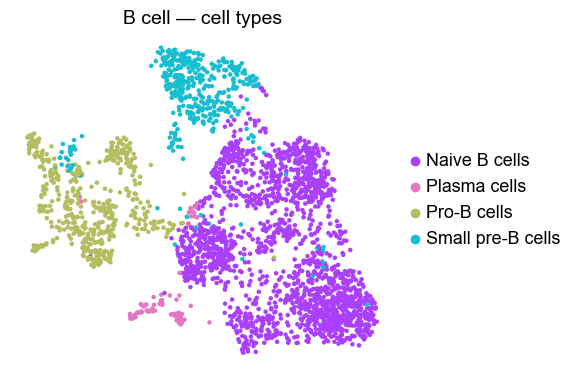

### B4 — Set the root cell

Same strategy as before, but root in **Pro-B cells** (from `celltypist_low`). Pick the Pro-B cell with the minimum DC1 value.

In [ ]:
# your code here


### B5 — Run DPT and sanity-check

Print mean pseudotime per cell type ordered as:
`['Pro-B cells', 'Small pre-B cells', 'Naive B cells', 'Plasma cells']`

Values should increase left-to-right.

In [ ]:
# your code here


### B6 — Visualise

Side-by-side UMAP (cell type | pseudotime) and a violin plot of pseudotime per cell type in the correct biological order.

In [ ]:
# your code here


> **Reference output:** B cell — cell type | DPT pseudotime UMAPs

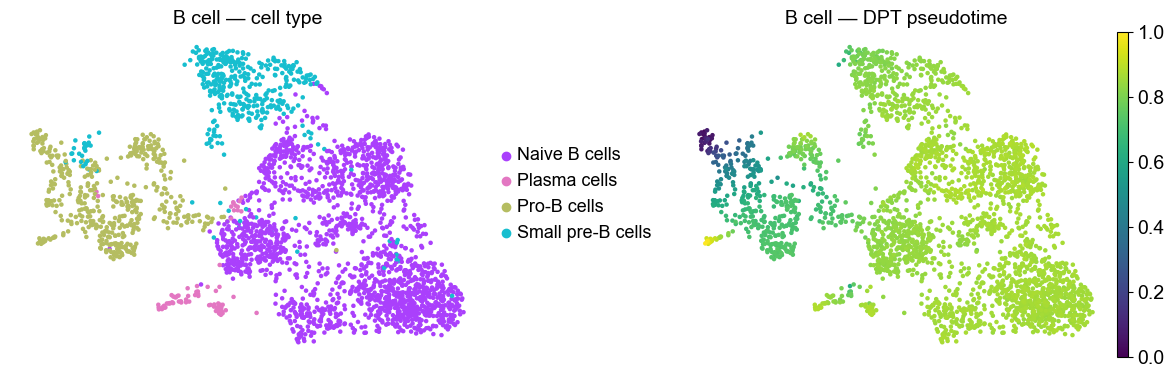

### B7 — Validate with known B cell markers

Plot these genes on the UMAP:
`VPREB1`, `IGLL1`, `CD79A`, `CD79B`, `MS4A1`, `MZB1`, `JCHAIN`

Early markers (`VPREB1`, `IGLL1`) should peak at Pro-B / Small pre-B. Late markers (`MZB1`, `JCHAIN`) should peak at Plasma cells.

In [ ]:
# your code here


---
## Reflection questions

Answer these in the cell below as comments or markdown:

1. Why did we recompute HVGs and neighbours on the subset rather than reusing the ones from the full `adata`?
2. Why do we choose the root cell from the *minimum* of DC1, rather than just picking any cell from the progenitor population at random?
3. The p-values from `sc.tl.rank_genes_groups` (DEG analysis) are described as "artificially low" in the scanpy tutorial. Does the same caveat apply to pseudotime? Why or why not?
4. If the mean pseudotime of your cell types did **not** increase in the expected biological order, what would you investigate first?

*your answers here*